In [15]:
!pip install prince -q

import pandas as pd
import kagglehub
import altair as alt

# Run this whole block TWICE!
# First time thru, Colab complains that we're using an old version of Kaggle
# But the second time works fine :)
path = kagglehub.dataset_download("sigmaborov/wids-2026-external-seasonal-wildfire-risk-features")

# Print filepath in Google drive
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'wids-2026-external-seasonal-wildfire-risk-features' dataset.
Path to dataset files: /kaggle/input/wids-2026-external-seasonal-wildfire-risk-features


In [16]:
# concat 'path' variable with name of file, and set delimiter to commas
df = pd.read_csv(path + '/WiDS 2026 External Seasonal Wildfire Risk Features.csv', delimiter=',')

# The path is should look something like: /kaggle/input/wids-2026-external-seasonal-wildfire-risk-features/WiDS 2026 External Seasonal Wildfire Risk Features.csv

# test to see if DataFrame is loaded correctly
df.head()


,Country,Region,Cause,year,month,fires_count,burned_area_ha,temperature_c,humidity_percent,wind_speed_kmh
0,Turkey,Mugla,Lightning,1881,8,353,76920,33,91,25
1,Turkey,Antalya,Lightning,1881,7,154,64920,38,34,39
2,Turkey,Izmir,Unknown,1881,6,196,83204,36,93,50
3,Spain,Catalonia,Lightning,1881,7,63,84578,42,64,16
4,Spain,Andalusia,Deforestation,1881,10,450,84754,17,55,8


In [17]:
# Isolate rows from USA
df_USA = df[df['Country'].str.contains('USA')]

# Force df_USA columns to be indexed 0 to length - 1.  This is required for the pd.concat() method later!!
df_USA = df_USA.reset_index()

In [18]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# isolate categorical data
df_USACat = df_USA[['Region','Cause']]

df_encoded = pd.DataFrame(encoder.fit_transform(df_USACat), columns=encoder.get_feature_names_out(df_USACat.columns))

print("USA dataset after One-Hot Encoding Categorical Attributes:")
display(df_encoded)
#df_USA[""]

USA dataset after One-Hot Encoding Categorical Attributes:


,Region_California,Region_Oregon,Region_Texas,Cause_Climate Change,Cause_Deforestation,Cause_Human,Cause_Lightning,Cause_Unknown
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
430,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
431,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
432,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
433,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [19]:
df_USA_dropped = df_USA.drop(columns=['Region', 'Cause', 'Country'], errors='ignore')

df_USA_concat = pd.concat([df_USA_dropped, df_encoded], axis=1)

df_USA_adjusted = df_USA_concat.dropna()

df_USA_adjusted = df_USA_adjusted.drop(columns=['index'])

df_USA_adjusted

,year,month,fires_count,burned_area_ha,temperature_c,humidity_percent,wind_speed_kmh,Region_California,Region_Oregon,Region_Texas,Cause_Climate Change,Cause_Deforestation,Cause_Human,Cause_Lightning,Cause_Unknown
0,1881,9,333,80138,18,93,61,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1881,10,246,43101,40,57,3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1881,8,96,23583,22,51,36,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1882,5,421,83979,15,15,58,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1882,5,438,47354,49,11,17,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,2024,6,52,90840,23,55,18,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
431,2024,6,343,75723,48,53,60,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
432,2025,6,5,13348,47,90,37,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
433,2025,9,88,21629,28,94,47,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [20]:
## PCA code referenced from Dimensionality Reduction Collab file provided on Canvas
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize the one-hot encoded data (important for PCA)
x_scaled = StandardScaler().fit_transform(df_USA_adjusted)

# Apply PCA
pca_categorical = PCA(n_components=2) # Reduce to 2 principal components for visualization
principal_components_categorical = pca_categorical.fit_transform(x_scaled)

# Create a DataFrame with the principal components
pca_df_categorical = pd.DataFrame(
    data=principal_components_categorical,
    columns=['Principal Component 1', 'Principal Component 2']
)

print("\nExplained Variance Ratio by each Principal Component (after encoding):")
display(pca_categorical.explained_variance_ratio_)

print("Total Explained Variance (after encoding):", sum(pca_categorical.explained_variance_ratio_))


Explained Variance Ratio by each Principal Component (after encoding):


array([0.10995404, 0.10591012])

Total Explained Variance (after encoding): 0.2158641650363725


In [21]:
import numpy as np
# Merge the original DataFram e 'df' with the PCA results 'pca_df_categorical'
chart_data = pd.concat([pca_df_categorical.reset_index(drop=True), df_USA.reset_index(drop=True)], axis=1)

# Add "Jitter" (tiny random noise) to separate overlapping points
np.random.seed(42) # This ensures the random shift looks the same every time you run it

# We use a standard deviation of 0.03 for the noise. Adjust if points are still too close or too spread out.
chart_data['Principal Component 1 Jittered'] = chart_data['Principal Component 1'] + np.random.normal(0, 0.03, size=len(chart_data))
chart_data['Principal Component 2 Jittered'] = chart_data['Principal Component 2'] + np.random.normal(0, 0.03, size=len(chart_data))

chart_pca = alt.Chart(chart_data).mark_circle(size=100, opacity=0.7).encode(
    # Plot using the jittered columns
    x=alt.X('Principal Component 1 Jittered', title='Principal Component 1'),
    y=alt.Y('Principal Component 2 Jittered', title='Principal Component 2'),
    # Use 'Sex' for color encoding to distinguish points by gender
    color=alt.Color('Cause', title='Cause'),
    # Include all original categorical features AND TRUE coordinates in the tooltip
    tooltip=['Region', 'Cause', 'fires_count','Principal Component 1', 'Principal Component 2']
).properties(
    title='PCA of One-Hot Encoded Wildfire areas with Causes (Jittered)',
    width=600,
    height=500
).interactive() # Allows zooming and panning

chart_pca

alt.Chart(...)

In [22]:
## FAMD code referenced from Dimensionality Reduction Collab file provided on Canvas

import prince
# Add a synthetic numerical column to df to satisfy FAMD requirements
# This is done to demonstrate FAMD with mixed data, even if the original data was purely categorical.
df_famd = df_USA.copy()
df_famd['Numerical_Feature'] = np.random.rand(len(df_famd)) * 100

print("DataFrame with added Numerical Feature for FAMD:")
display(df_famd.head())

# Initialize the FAMD model
# n_components=2 allows us to plot the results on a 2D graph
famd = prince.FAMD(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# Fit the model to our modified dataframe
famd = famd.fit(df_famd)

print("Eigenvalues (Variance explained by each component) for FAMD:")
display(famd.eigenvalues_summary)

DataFrame with added Numerical Feature for FAMD:


,index,Country,Region,Cause,year,month,fires_count,burned_area_ha,temperature_c,humidity_percent,wind_speed_kmh,Numerical_Feature
0,5,USA,California,Lightning,1881,9,333,80138,18,93,61,8.698676
1,6,USA,Texas,Human,1881,10,246,43101,40,57,3,40.845321
2,7,USA,Oregon,Unknown,1881,8,96,23583,22,51,36,37.268852
3,33,USA,California,Lightning,1882,5,421,83979,15,15,58,25.975378
4,34,USA,Texas,Lightning,1882,5,438,47354,49,11,17,72.342011


Eigenvalues (Variance explained by each component) for FAMD:


,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,27.005,0.33%,0.33%
1,26.970,0.33%,0.66%


In [23]:
# Extract the coordinates for all features (categorical and numerical) from the fitted FAMD model
# The .column_coordinates_ attribute extracts the coordinates for all variables.

# Get coordinates for all variables
all_coords = famd.column_coordinates_.reset_index()
all_coords.columns = ['Category','Component 0', 'Component 1']

# Add "Jitter" (tiny random noise) to separate overlapping points
# This helps in visualizing points that might otherwise lie exactly on top of each other.
np.random.seed(42) # Ensure reproducibility of jitter

# Apply jitter to both components
all_coords['Component 0 Jittered'] = all_coords['Component 0'] + np.random.normal(0, 0.03, size=len(all_coords))
all_coords['Component 1 Jittered'] = all_coords['Component 1'] + np.random.normal(0, 0.03, size=len(all_coords))

# Build the Altair chart using the jittered coordinates
chart_famd = alt.Chart(all_coords).mark_circle(size=150, opacity=0.7).encode(
    # Use jittered components for plotting positions
    x=alt.X('Component 0 Jittered', title='FAMD Component 0'),
    y=alt.Y('Component 1 Jittered', title='FAMD Component 1'),
    color=alt.Color('Category', legend=None), # Color by category, remove legend for cleaner look
    # Show true coordinates in tooltip
    tooltip=['Category', 'Component 0', 'Component 1']
).properties(
    title='FAMD: Wildfire Feature Coordinates (Jittered for clarity)',
    width=700,
    height=500
).interactive() # Enable zooming and panning

# Display the chart
chart_famd

alt.Chart(...)

<Axes: >

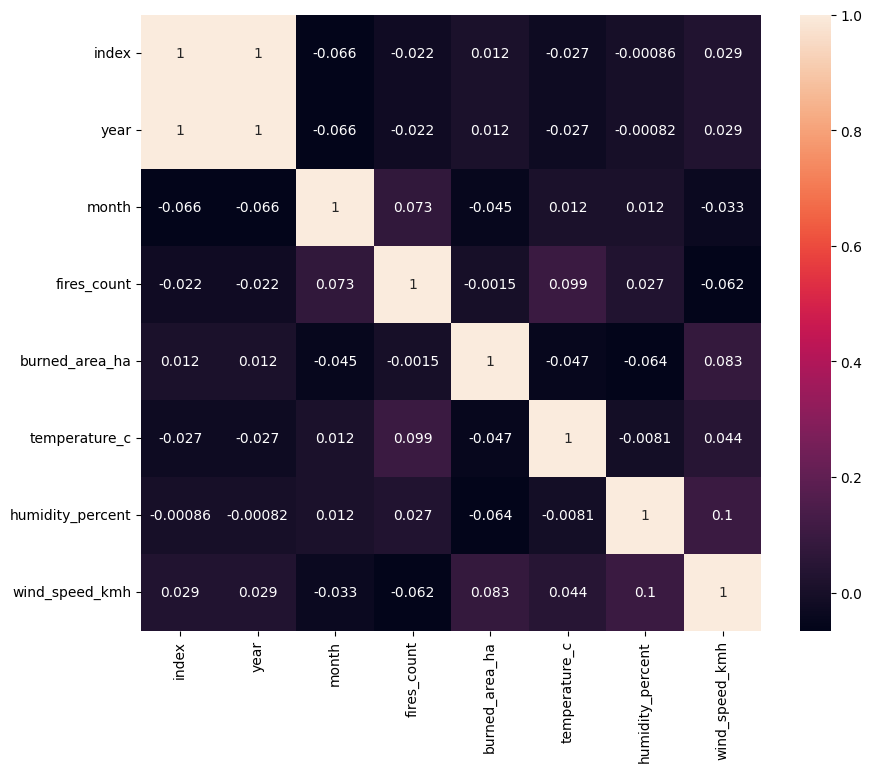

In [24]:
#Used in-class practice 3 collab file to create heatmaps
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df_USA.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True)





<Axes: >

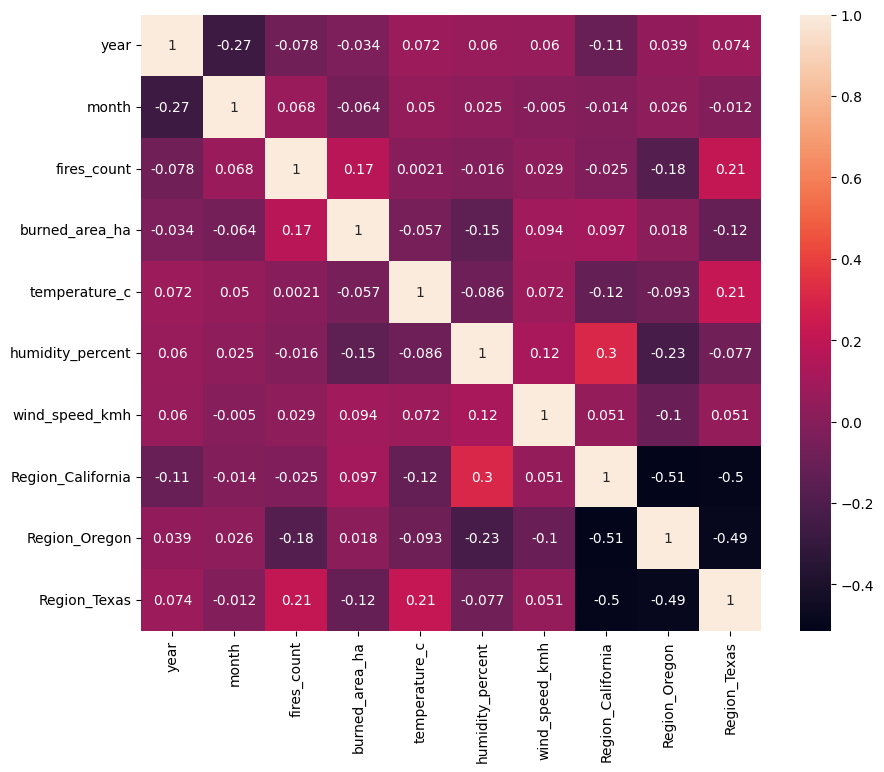

In [25]:
df_lightning = df_USA_adjusted[df_USA_adjusted['Cause_Lightning']==1]
df_lightning = df_lightning.drop(columns=['Cause_Lightning','Cause_Deforestation','Cause_Human','Cause_Lightning','Cause_Unknown','Cause_Climate Change'])


numeric_df_lightning = df_lightning.select_dtypes(include='number')


plt.figure(figsize=(10,8))
sns.heatmap(numeric_df_lightning.corr(), annot=True)
##Relation between humidity percent and California
##Relation between fire count and texas
##Relation between temperature and texas

<Axes: >

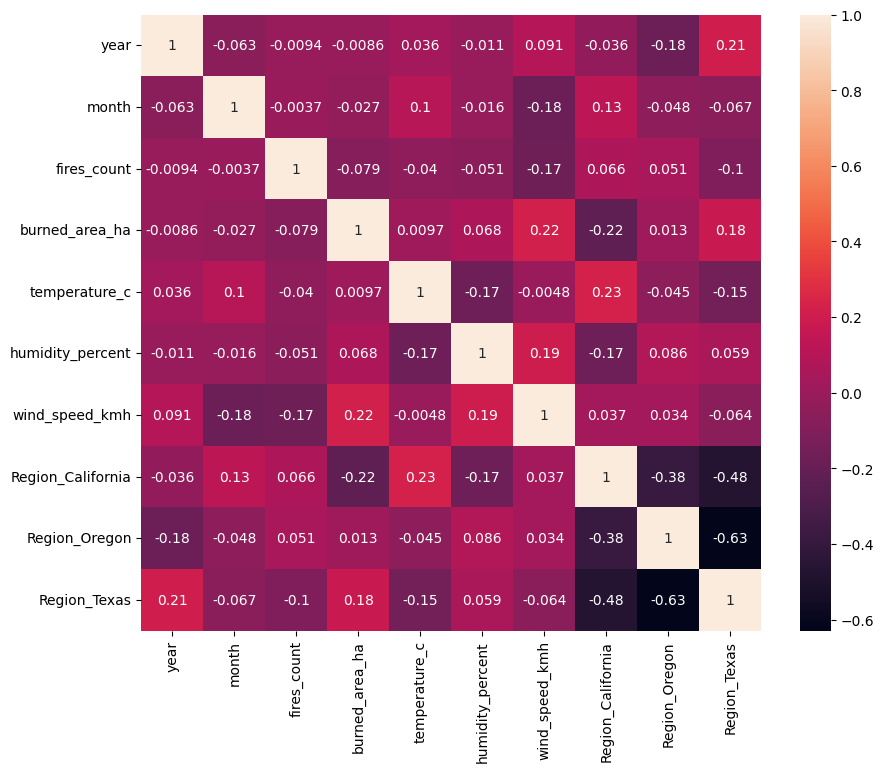

In [26]:
df_Cause_ClimateChange = df_USA_adjusted[df_USA_adjusted['Cause_Climate Change']==1]
df_Cause_ClimateChange = df_Cause_ClimateChange.drop(columns=['Cause_Lightning','Cause_Deforestation','Cause_Human','Cause_Lightning','Cause_Unknown','Cause_Climate Change'])




numeric_df_climatechange = df_Cause_ClimateChange.select_dtypes(include='number')


plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df_climatechange.corr(), annot=True)

##Relation between year and Texas
##Relation between temperature and California
##Relation between burn area and wind_speed

<Axes: >

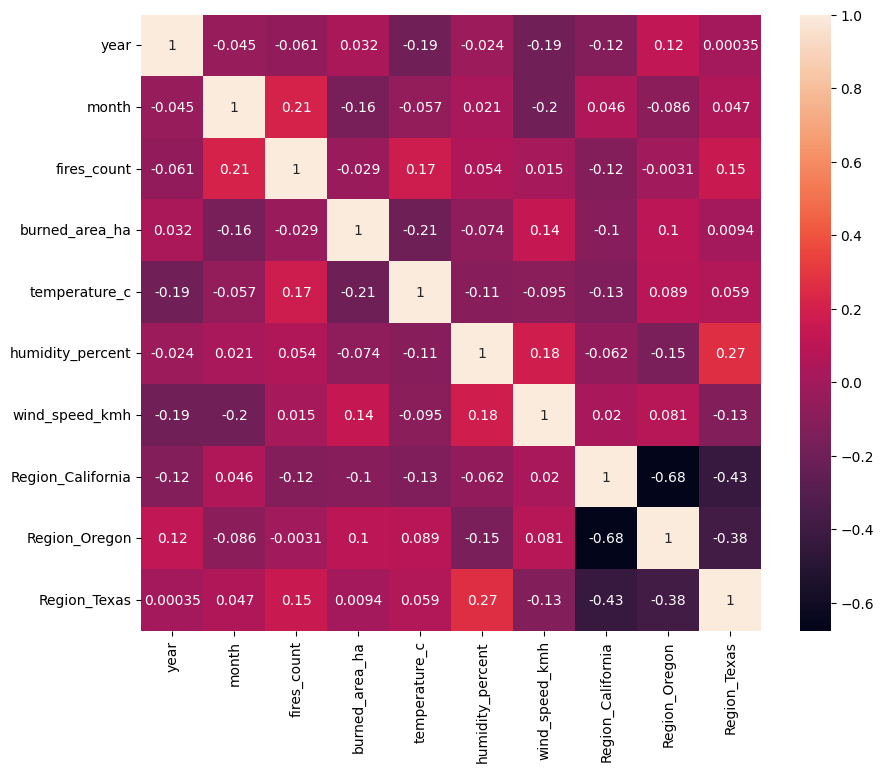

In [13]:
df_Cause_Deforestation = df_USA_adjusted[df_USA_adjusted['Cause_Deforestation']==1]
df_Cause_Deforestation = df_Cause_Deforestation.drop(columns=['Cause_Lightning','Cause_Deforestation','Cause_Human','Cause_Lightning','Cause_Unknown','Cause_Climate Change'])




numeric_df_deforestation = df_Cause_Deforestation.select_dtypes(include='number')


plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df_deforestation.corr(), annot=True)

##Relation between humidity percent and Texas
##Relation betweeen temperature and California
##Relation between years and Texas

<Axes: >

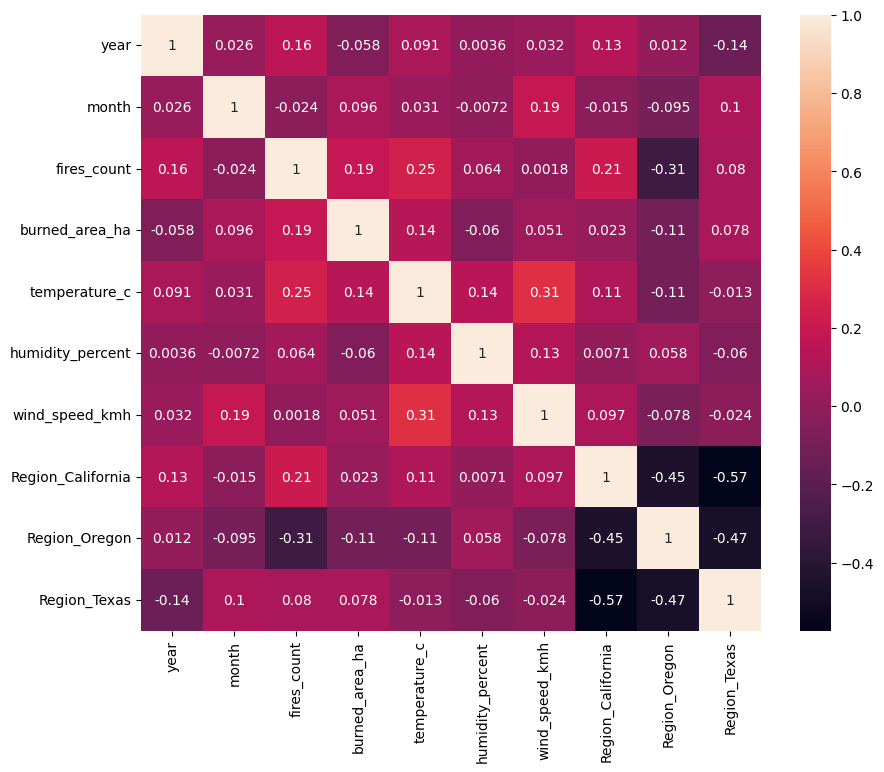

In [14]:
df_Cause_Unknown = df_USA_adjusted[df_USA_adjusted['Cause_Unknown']==1]
df_Cause_Unknown = df_Cause_Unknown.drop(columns=['Cause_Lightning','Cause_Deforestation','Cause_Human','Cause_Lightning','Cause_Unknown','Cause_Climate Change'])




numeric_df_causeunknown = df_Cause_Unknown.select_dtypes(include='number')


plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df_causeunknown.corr(), annot=True)

##Relation between windspeed and temperature
##Relation between temperature and firecount